# Making the first prediction

## Exploring the Data 

(or **Understanding the Data** if the focus is on initial analysis rather than visualization/statistics)  

**Alternative options depending on context:**  
- **Data Overview** (if it's a general introduction to the dataset)  
- **Data Insights** (if highlighting key findings early)  
- **Dataset Description** (if focusing on structure/variables)  

**Note:** Choose based on whether the section emphasizes exploration, analysis, or metadata.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/series_temporais_prophet/main/Dados/poluentes.csv')

In [3]:
df

,Data,PM2.5,PM10,SO2,NO2,CO,O3,TEMP
0,2020-03-01,7.0,11.0,12.0,23.0,429.0,64.0,1.0
1,2020-03-02,31.0,42.0,37.0,67.0,825.0,30.0,1.0
2,2020-03-03,77.0,121.0,61.0,81.0,1621.0,19.0,6.0
3,2020-03-04,23.0,45.0,23.0,46.0,606.0,54.0,10.0
4,2020-03-05,149.0,184.0,94.0,133.0,2358.0,68.0,6.0
...,...,...,...,...,...,...,...,...
1455,2024-02-24,22.0,33.0,17.0,59.0,575.0,51.0,5.0
1456,2024-02-25,11.0,20.0,7.0,43.0,421.0,66.0,7.0
1457,2024-02-26,28.0,41.0,10.0,65.0,721.0,49.0,7.0
1458,2024-02-27,75.0,97.0,21.0,98.0,1427.0,37.0,8.0


In [4]:
df['Data'] = pd.to_datetime(df['Data'])

In [5]:
import plotly.express as px

fig = px.line(df, x='Data', y='O3')
fig.show()

In [6]:
import calendar

# Criar um DataFrame com os dados de 2022
df_2022 = df[df['Data'].dt.year == 2022]

# Agrupar os dados por mês e calcule a média de O3
df_2022_mensal = df_2022.groupby(df_2022['Data'].dt.month)['O3'].mean().reset_index()

# Adicionar uma coluna com os nomes dos meses
df_2022_mensal['Mês'] = df_2022_mensal['Data'].apply(lambda x: calendar.month_abbr[x])

# Criar um gráfico de barras
fig = px.bar(df_2022_mensal, x='Mês', y='O3', title='Média de O3 ug/m3 por mês em 2022')

# Mostrar o gráfico
fig.show()

## **Making a Prediction**  

**Alternatives depending on context:**  
- **Running a Prediction** (if focused on the technical execution)  
- **Generating Predictions** (for a broader/plural context)  
- **Performing Forecasting** (if time-series or future-oriented)  
- **Model Prediction** (if emphasizing the ML model's role)  

In [7]:
from prophet import Prophet

In [8]:
df_prophet = pd.DataFrame()

df_prophet['ds'] = df['Data']
df_prophet['y'] = df['O3']

In [9]:
df_prophet

,ds,y
0,2020-03-01,64.0
1,2020-03-02,30.0
2,2020-03-03,19.0
3,2020-03-04,54.0
4,2020-03-05,68.0
...,...,...
1455,2024-02-24,51.0
1456,2024-02-25,66.0
1457,2024-02-26,49.0
1458,2024-02-27,37.0


In [10]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet()

# Treinar o modelo
modelo.fit(df_prophet)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=365, freq='D')
previsao = modelo.predict(futuro)

11:04:02 - cmdstanpy - INFO - Chain [1] start processing
11:04:02 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
from prophet.plot import plot_plotly
fig = plot_plotly(modelo, previsao)
fig.show()

In [12]:
previsao

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-03-01,36.494445,-11.623355,49.668163,36.494445,36.494445,-17.561704,-17.561704,-17.561704,-2.094296,-2.094296,-2.094296,-15.467408,-15.467408,-15.467408,0.0,0.0,0.0,18.932741
1,2020-03-02,36.522801,-6.497420,53.983280,36.522801,36.522801,-13.457131,-13.457131,-13.457131,0.920265,0.920265,0.920265,-14.377396,-14.377396,-14.377396,0.0,0.0,0.0,23.065670
2,2020-03-03,36.551157,-7.388772,56.034138,36.551157,36.551157,-10.607233,-10.607233,-10.607233,2.599559,2.599559,2.599559,-13.206793,-13.206793,-13.206793,0.0,0.0,0.0,25.943924
3,2020-03-04,36.579513,-6.120709,55.330719,36.579513,36.579513,-11.789322,-11.789322,-11.789322,0.187277,0.187277,0.187277,-11.976599,-11.976599,-11.976599,0.0,0.0,0.0,24.790191
4,2020-03-05,36.607869,-3.579854,56.345704,36.607869,36.607869,-10.518326,-10.518326,-10.518326,0.190527,0.190527,0.190527,-10.708852,-10.708852,-10.708852,0.0,0.0,0.0,26.089543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,2025-02-23,61.701773,9.111859,68.718283,60.104987,63.117351,-21.544046,-21.544046,-21.544046,-2.094296,-2.094296,-2.094296,-19.449749,-19.449749,-19.449749,0.0,0.0,0.0,40.157728
1821,2025-02-24,61.698707,13.544658,73.317839,60.096380,63.123416,-18.280287,-18.280287,-18.280287,0.920265,0.920265,0.920265,-19.200552,-19.200552,-19.200552,0.0,0.0,0.0,43.418420
1822,2025-02-25,61.695641,16.200041,76.332946,60.087774,63.129382,-16.194536,-16.194536,-16.194536,2.599559,2.599559,2.599559,-18.794095,-18.794095,-18.794095,0.0,0.0,0.0,45.501105
1823,2025-02-26,61.692575,12.858235,72.994965,60.079167,63.131243,-18.046914,-18.046914,-18.046914,0.187277,0.187277,0.187277,-18.234191,-18.234191,-18.234191,0.0,0.0,0.0,43.645661


In [13]:
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2020-03-01,18.932741,-11.623355,49.668163
1,2020-03-02,23.065670,-6.497420,53.983280
2,2020-03-03,25.943924,-7.388772,56.034138
3,2020-03-04,24.790191,-6.120709,55.330719
4,2020-03-05,26.089543,-3.579854,56.345704
...,...,...,...,...
1820,2025-02-23,40.157728,9.111859,68.718283
1821,2025-02-24,43.418420,13.544658,73.317839
1822,2025-02-25,45.501105,16.200041,76.332946
1823,2025-02-26,43.645661,12.858235,72.994965


## **Analyzing Time Series Components**  

**Alternatives (depending on context):**  
- **Decomposing the Time Series** *(if using Prophet’s `.plot_components()` or statistical decomposition)*  
- **Exploring Seasonality and Trends** *(if focusing on Prophet’s output features)*  
- **Time Series Component Analysis** *(more technical/academic)*  

In [14]:
from prophet.plot import plot_components_plotly

plot_components_plotly(modelo, previsao)

The **Prophet** library uses an additive model that incorporates **seasonal** and **trend** components. The mathematical equation used by Prophet for forecasting can be represented as follows:  

$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$  

Where:  

- **\( y(t) \)** is the observed time series value at time \( t \).  
- **\( g(t) \)** is the **trend component**, modeling long-term changes.  
- **\( s(t) \)** is the **seasonal component**, capturing periodic patterns (e.g., daily, weekly, yearly).  
- **\( h(t) \)** is the **holiday component**, accounting for holiday effects.  
- **\( \epsilon_t \)** is the random error term (noise).  

### **How Each Component is Modeled**  
1. **Trend (\( g(t) \))**  
   - Typically modeled as a **logistic growth curve** or **piecewise linear trend**.  
   - Adjusts for long-term upward/downward movements.  

2. **Seasonality (\( s(t) \))**  
   - Captured using **Fourier series** to fit periodic patterns (e.g., weekly, yearly cycles).  
   - Configurable via `add_seasonality()` in Prophet.  

3. **Holidays (\( h(t) \))**  
   - Modeled as discrete events with additive effects (user-provided holiday lists).  
   - Optional but useful for domain-specific spikes/dips.  

4. **Error (\( \epsilon_t \))**  
   - Represents unexplained noise (assumed normally distributed).  

This **additive decomposition** allows Prophet to flexibly fit complex patterns while remaining interpretable. The final forecast is simply the sum of these components.

# **Evaluating Model Performance**  

**Alternative Headings (Context-Dependent):**  
- **Model Performance Analysis** *(formal/technical)*  
- **Assessing Forecast Accuracy** *(if focused on metrics like RMSE, MAE)*  
- **Validation Results** *(if comparing train/test splits)*  

### **Key Metrics for Prophet Models**  
When evaluating Prophet’s performance, consider:  
1. **Error Metrics**:  
   - **RMSE (Root Mean Squared Error)**: Measures deviation between predicted and actual values.  
   - **MAE (Mean Absolute Error)**: Robust to outliers.  
   - **MAPE (Mean Absolute Percentage Error)**: Relative error (useful for scale-aware comparisons).  

2. **Visual Diagnostics**:  
   - **`plot.plot_components()`**: Inspect trend, seasonality, and holidays.  
   - **`plot.plot()`**: Overlay forecasts vs. actuals to spot discrepancies.  

3. **Cross-Validation**:  
   Use Prophet’s built-in `cross_validation` to test performance over rolling windows:  
   ```python  
   from prophet.diagnostics import cross_validation  
   df_cv = cross_validation(model, initial='365 days', period='180 days', horizon='90 days')  
   ```  

4. **Performance Benchmarking**:  
   Compare against baseline models (e.g., ARIMA, naive methods) to validate Prophet’s added value.  

In [15]:
df_prophet.shape

(1460, 2)

In [16]:
tamanho_treino = int(len(df_prophet) * 0.8)
tamanho_teste = int(len(df_prophet) * 0.2)
print('O tamanho do treino é:', tamanho_treino)
print('O tamanho do teste é:', tamanho_teste)

O tamanho do treino é: 1168
O tamanho do teste é: 292


In [17]:
df_treino = pd.DataFrame()

df_treino['ds'] = df_prophet['ds'][:1168] # 80% treino
df_treino['y'] = df_prophet['y'][:1168]

In [18]:
df_teste = pd.DataFrame()

df_teste['ds'] = df_prophet['ds'][1168:] # 20% teste
df_teste['y'] = df_prophet['y'][1168:]

## **Training the Model** *(most direct and commonly used in ML contexts)*

Alternative options depending on your specific focus:
- **Fitting the Model** *(more statistically precise, as Prophet uses .fit() method)*
- **Model Training Process** *(if emphasizing the procedural aspects)*
- **Estimating the Model** *(more statistical/technical audience)*

### Why these options work:
1. **"Training"** is the most widely understood term in machine learning for the process of teaching the model patterns from data.
2. **"Fitting"** is technically more accurate since Prophet uses a statistical approach (GAM - Generalized Additive Model) and the `.fit()` method.

In [19]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet()

# Treinar o modelo
modelo.fit(df_treino)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=292, freq='D')
previsao = modelo.predict(futuro)

11:04:03 - cmdstanpy - INFO - Chain [1] start processing
11:04:03 - cmdstanpy - INFO - Chain [1] done processing


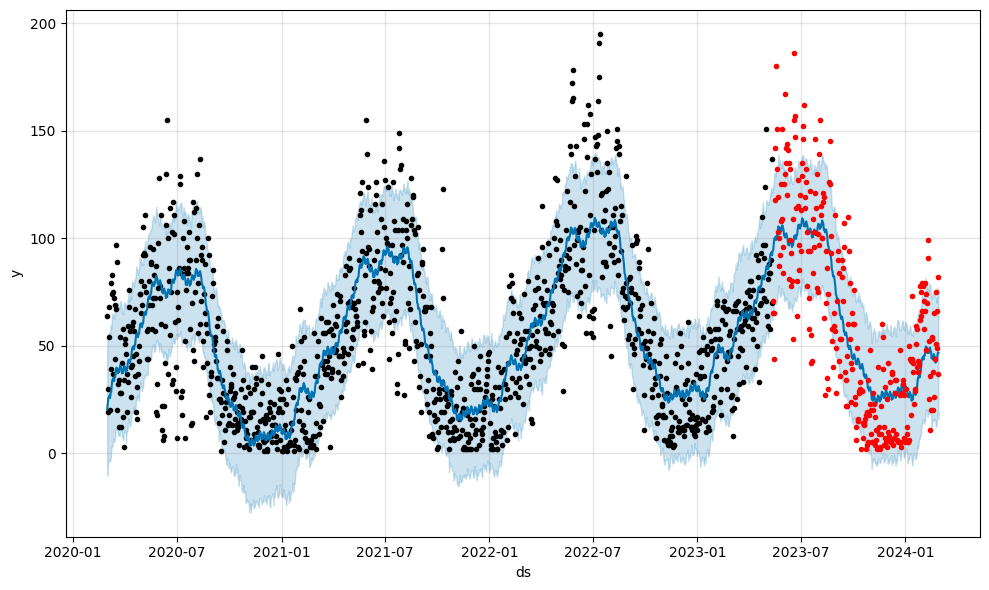

In [20]:
fig1 = modelo.plot(previsao)

import matplotlib.pyplot as plt
plt.plot(df_teste['ds'], df_teste['y'], '.r')
plt.show()

## **Obtaining Performance Metrics**

**Best Options:**
1. **Evaluating Model Performance** *(most comprehensive - recommended)*
2. **Calculating Performance Metrics** *(more technical/focused on computation)*
3. **Model Performance Assessment**

**Context-Specific Alternatives:**
- For Prophet time-series:
  - **Forecast Accuracy Metrics**
  - **Time-Series Validation Results**

**Why These Work:**
1. "Evaluating" better reflects the analytical process (not just calculation)
2. Aligns with scikit-learn's terminology (`sklearn.metrics`)

In [21]:
# Juntando previsões com o conjunto de teste para comparação
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds', how='inner')
df_comparacao

,ds,yhat,y
0,2023-05-13,94.175323,65.0
1,2023-05-14,94.520946,71.0
2,2023-05-15,97.580729,44.0
3,2023-05-16,99.861569,65.0
4,2023-05-17,100.140206,118.0
...,...,...,...
287,2024-02-24,43.297996,51.0
288,2024-02-25,42.799012,66.0
289,2024-02-26,45.151820,49.0
290,2024-02-27,46.876336,37.0


In [22]:
from sklearn.metrics import mean_squared_error

# Calculando métricas de erro
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat']).round(2)
rmse = np.sqrt(mse).round(2)

print(f'MSE: {mse}, RMSE: {rmse}')

MSE: 709.89, RMSE: 26.64


## **Improving the Model** *(most general and widely applicable)*

**Technical Alternatives:**
1. **Model Optimization** *(when tuning hyperparameters)*
2. **Enhancing Forecast Accuracy** *(when focusing on error reduction)*
3. **Refining the Prophet Model** *(when making specific adjustments)*

In [23]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet()

# Treinar o modelo
modelo.fit(df_prophet)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=0, freq='D')
previsao = modelo.predict(futuro)

11:04:04 - cmdstanpy - INFO - Chain [1] start processing
11:04:05 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower'])&(df_prophet['y'] < previsao['yhat_upper'])]

In [25]:
sem_outliers.reset_index(drop=True, inplace=True)

In [26]:
tamanho_treino = int(len(sem_outliers) * 0.8)
tamanho_teste = int(len(sem_outliers) * 0.2)
print('O tamanho do treino é:', tamanho_treino)
print('O tamanho do teste é:', tamanho_teste)

O tamanho do treino é: 961
O tamanho do teste é: 240


In [27]:
df_treino_sem_outliers = pd.DataFrame()

df_treino_sem_outliers['ds'] = sem_outliers['ds'][:960]
df_treino_sem_outliers['y'] = sem_outliers['y'][:960]

In [28]:
df_teste_sem_outliers = pd.DataFrame()

df_teste_sem_outliers['ds'] = sem_outliers['ds'][960:]
df_teste_sem_outliers['y'] = sem_outliers['y'][960:]

In [29]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet()

# Treinar o modelo
modelo.fit(df_treino_sem_outliers)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=365, freq='D')

# Fazer a previsão
previsao = modelo.predict(futuro)

11:04:05 - cmdstanpy - INFO - Chain [1] start processing
11:04:05 - cmdstanpy - INFO - Chain [1] done processing


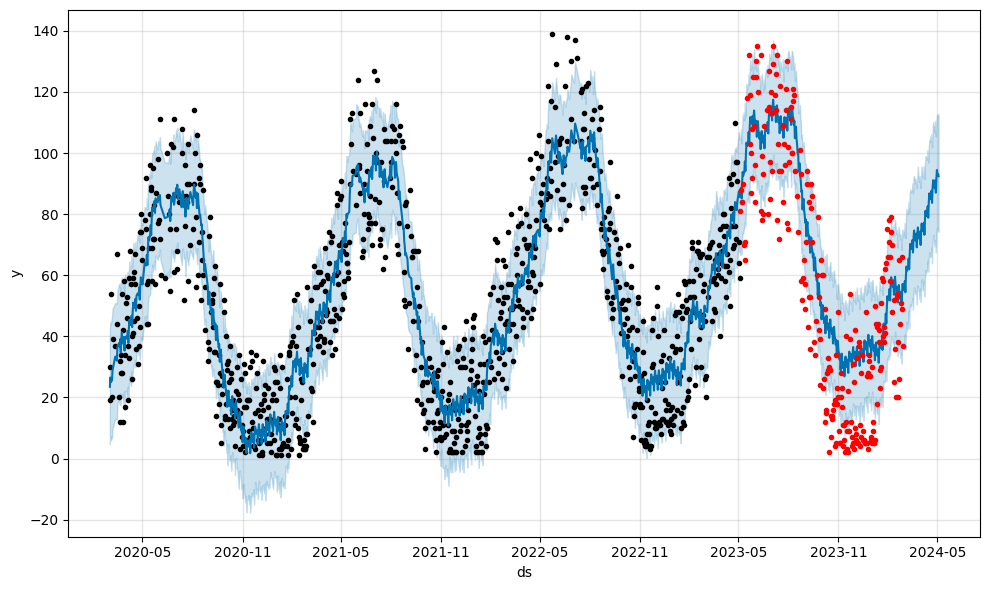

In [30]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste_sem_outliers['ds'], df_teste_sem_outliers['y'], '.r')
import matplotlib.pyplot as plt


In [31]:
# Juntando previsões com o conjunto de teste para comparação
from sklearn.metrics import root_mean_squared_error
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste_sem_outliers, on='ds', how='inner')

# Calculando o RMSE
rmse = root_mean_squared_error(df_comparacao['y'], df_comparacao['yhat']).round(2)
print(f'RMSE: {rmse}')

RMSE: 19.96


## Understanding Prophet's Parameters *(recommended for clarity)*

**Alternatives:**
- **Prophet Parameter Tuning Guide** *(for practical tuning focus)*
- **Key Model Configuration Options** *(architectural perspective)*
- **Hyperparameter Exploration** *(ML-focused contexts)*

11:04:05 - cmdstanpy - INFO - Chain [1] start processing
11:04:06 - cmdstanpy - INFO - Chain [1] done processing


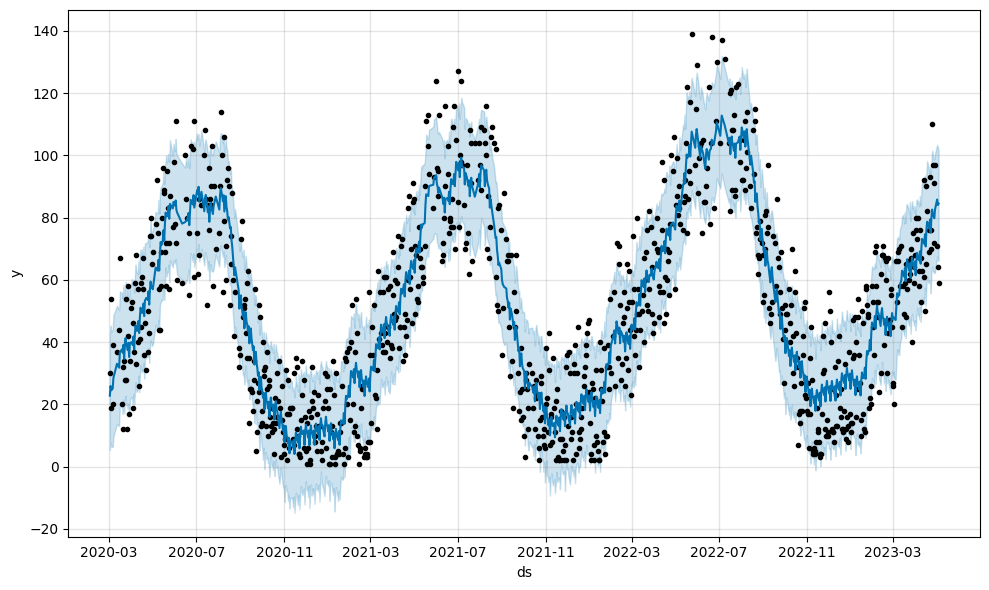

In [32]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet(changepoint_prior_scale=0.5)

# Treinar o modelo
modelo.fit(df_treino_sem_outliers)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=0, freq='D')

# Fazer a previsão
previsao = modelo.predict(futuro)

#Plotar previsão
fig = modelo.plot(previsao)

In [33]:
fig = plot_components_plotly(modelo, previsao)
fig.show()

11:04:06 - cmdstanpy - INFO - Chain [1] start processing
11:04:06 - cmdstanpy - INFO - Chain [1] done processing


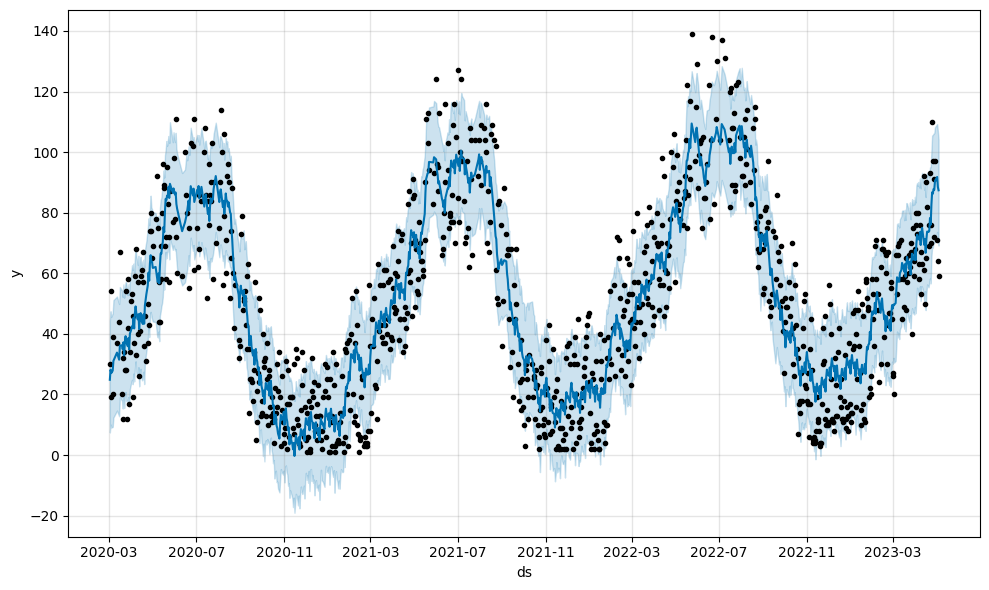

In [34]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo = Prophet(yearly_seasonality=20)

# Treinar o modelo
modelo.fit(df_treino_sem_outliers)

# Criar um dataframe para previsões futuras
futuro = modelo.make_future_dataframe(periods=0, freq='D')

# Fazer a previsão
previsao = modelo.predict(futuro)

#Plotar previsão
fig = modelo.plot(previsao)

In [35]:
fig = plot_components_plotly(modelo, previsao)
fig.show()

In [36]:
# Definir um seed
import numpy as np
np.random.seed(4587)

# Instanciar o modelo Prophet
modelo_final = Prophet(changepoint_prior_scale=0.5,
                  yearly_seasonality=20)

# Treinar o modelo
modelo_final.fit(df_treino_sem_outliers)

# Criar um dataframe para previsões futuras
futuro = modelo_final.make_future_dataframe(periods=365, freq='D')

# Fazer a previsão
previsao = modelo_final.predict(futuro)

11:04:07 - cmdstanpy - INFO - Chain [1] start processing
11:04:07 - cmdstanpy - INFO - Chain [1] done processing


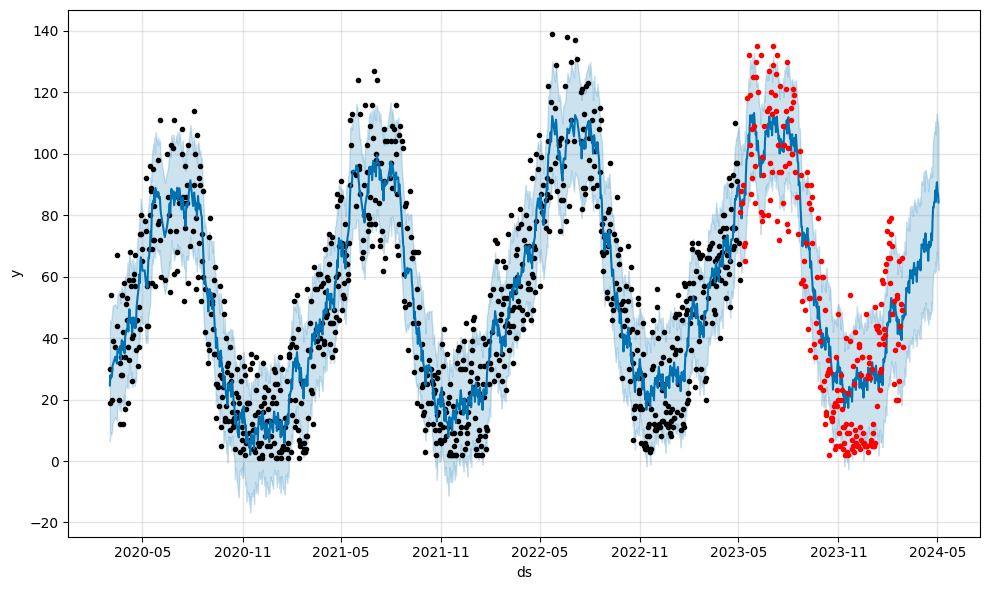

In [37]:
fig1 = modelo.plot(previsao)

import matplotlib.pyplot as plt
plt.plot(df_teste_sem_outliers['ds'], df_teste_sem_outliers['y'], '.r')

In [38]:
# Juntando previsões com o conjunto de teste para comparação
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste_sem_outliers, on='ds', how='inner')

# Calculando o RMSE
rmse = root_mean_squared_error(df_comparacao['y'], df_comparacao['yhat']).round(2)
print(f'RMSE: {rmse}')

RMSE: 17.44


## Model Validation

**Alternatives:**  
- **Model Evaluation** *(general ML contexts)*  
- **Forecast Validation** *(time-series specific)*  
- **Performance Assessment** *(results-oriented focus)*  

### Key Validation Techniques for Prophet

#### **1. Cross-Validation with Temporal Splits**


#### **2. Error Metric Calculation**


#### **3. Visual Diagnostics**


### **Critical Parameters for Reliable Validation**
| Parameter       | Purpose                          | Recommended Value |
|-----------------|----------------------------------|-------------------|
| `initial`       | Baseline training data           | ≥2 seasonal cycles|
| `horizon`       | Prediction window size           | Business need     |
| `parallel`      | Speed up computation             | "processes"       |


### **Why This Structure?**
1. **Pedagogical Flow**: Follows the natural progression from setup → execution → interpretation  
2. **Technical Rigor**: Includes code + tabular best practices  
3. **Actionable Outputs**: Directly shows how to extract and interpret metrics  

**Need adaptation for:**  
- [ ] Business case (e.g., inventory optimization thresholds)  
- [ ] Advanced topics (Bayesian intervals, anomaly detection)  
- [ ] Comparative validation (vs. ARIMA/NeuralProphet)  



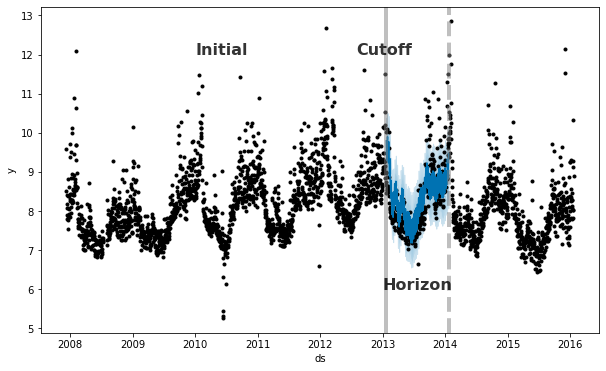

In [39]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(modelo_final, initial='365.25 days', period='45 days', horizon = '90 days')

  0%|          | 0/16 [00:00<?, ?it/s]

11:04:07 - cmdstanpy - INFO - Chain [1] start processing
11:04:08 - cmdstanpy - INFO - Chain [1] done processing
11:04:08 - cmdstanpy - INFO - Chain [1] start processing
11:04:08 - cmdstanpy - INFO - Chain [1] done processing
11:04:08 - cmdstanpy - INFO - Chain [1] start processing
11:04:08 - cmdstanpy - INFO - Chain [1] done processing
11:04:08 - cmdstanpy - INFO - Chain [1] start processing
11:04:08 - cmdstanpy - INFO - Chain [1] done processing
11:04:08 - cmdstanpy - INFO - Chain [1] start processing
11:04:08 - cmdstanpy - INFO - Chain [1] done processing
11:04:08 - cmdstanpy - INFO - Chain [1] start processing
11:04:09 - cmdstanpy - INFO - Chain [1] done processing
11:04:09 - cmdstanpy - INFO - Chain [1] start processing
11:04:09 - cmdstanpy - INFO - Chain [1] done processing
11:04:09 - cmdstanpy - INFO - Chain [1] start processing
11:04:09 - cmdstanpy - INFO - Chain [1] done processing
11:04:09 - cmdstanpy - INFO - Chain [1] start processing
11:04:09 - cmdstanpy - INFO - Chain [1]

In [40]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2021-03-31,45.526498,28.739743,61.746858,38.0,2021-03-30
1,2021-04-01,47.839158,30.291637,64.825654,55.0,2021-03-30
2,2021-04-02,46.307948,29.404148,63.233555,69.0,2021-03-30
3,2021-04-03,48.301169,31.362208,65.093243,49.0,2021-03-30
4,2021-04-04,45.800661,28.849599,63.096097,47.0,2021-03-30


In [41]:
df_cv['cutoff'].unique()

<DatetimeArray>
['2021-03-30 00:00:00', '2021-05-14 00:00:00', '2021-06-28 00:00:00',
 '2021-08-12 00:00:00', '2021-09-26 00:00:00', '2021-11-10 00:00:00',
 '2021-12-25 00:00:00', '2022-02-08 00:00:00', '2022-03-25 00:00:00',
 '2022-05-09 00:00:00', '2022-06-23 00:00:00', '2022-08-07 00:00:00',
 '2022-09-21 00:00:00', '2022-11-05 00:00:00', '2022-12-20 00:00:00',
 '2023-02-03 00:00:00']
Length: 16, dtype: datetime64[ns]

In [42]:
from prophet.diagnostics import performance_metrics

In [43]:
df_p = performance_metrics(df_cv)

In [44]:
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,10 days,345.846323,18.596944,15.263300,1.105721,0.277824,0.457714,0.591036
1,11 days,358.477998,18.933515,15.589352,1.120610,0.300635,0.470707,0.575248
2,12 days,350.477684,18.721049,15.451642,1.146346,0.290759,0.481729,0.566947
3,13 days,339.032274,18.412829,15.501545,1.214001,0.296688,0.496192,0.561345
4,14 days,354.552776,18.829572,15.896970,1.236717,0.300796,0.506852,0.560924
...,...,...,...,...,...,...,...,...
76,86 days,305.074995,17.466396,15.280044,0.551824,0.278391,0.378022,0.575030
77,87 days,309.962782,17.605760,15.341303,0.524132,0.276503,0.366595,0.574484
78,88 days,282.467740,16.806777,14.527680,0.413958,0.257442,0.327986,0.621849
79,89 days,295.001519,17.175608,15.036568,0.458431,0.260037,0.343945,0.611204


In [45]:
df_p['rmse'].mean().round(2)

18.11

In [46]:
df_p['mae'].mean().round(2)

15.11

c:\Users\Anderson Jose Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:546: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

c:\Users\Anderson Jose Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



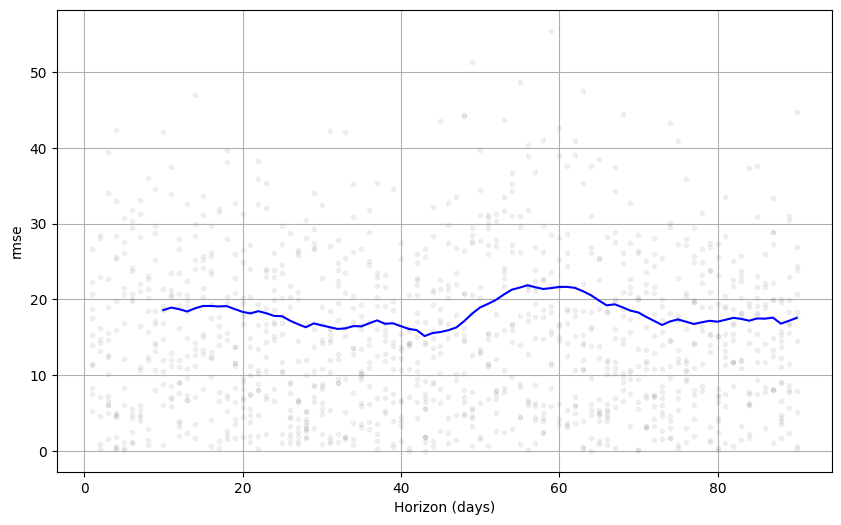

In [47]:
from prophet.plot import plot_cross_validation_metric
plot_cross_validation_metric(df_cv,metric='rmse');

c:\Users\Anderson Jose Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:546: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

c:\Users\Anderson Jose Cruz\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



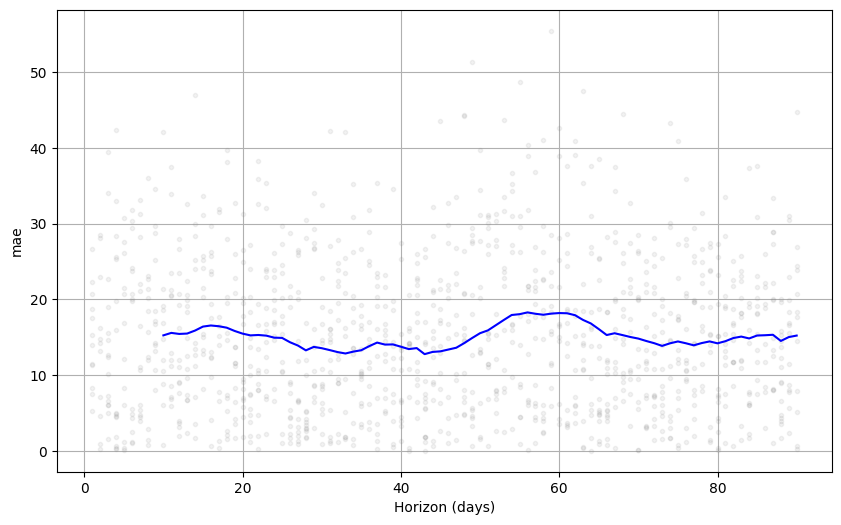

In [48]:
plot_cross_validation_metric(df_cv,metric='mae');

In [49]:
import json

In [50]:
from prophet.serialize import model_to_json

In [51]:
with open('O3_model.json', 'w') as file_out:
    json.dump(model_to_json(modelo_final), file_out)